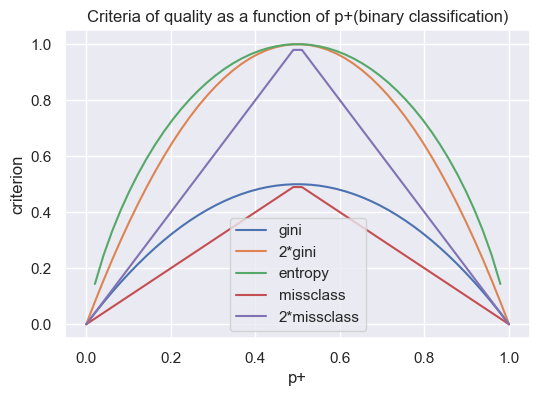

(200,)
(200, 2)


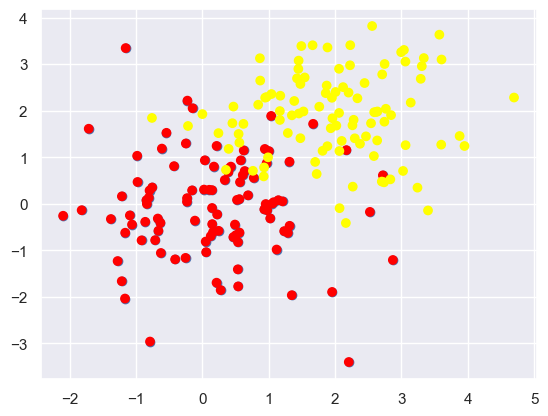

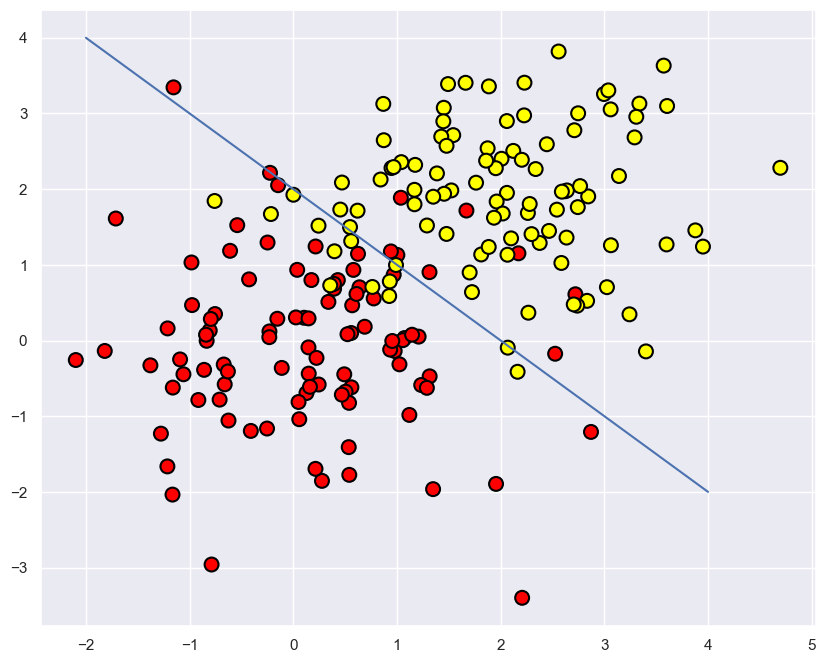

(200, 1)
(200,)


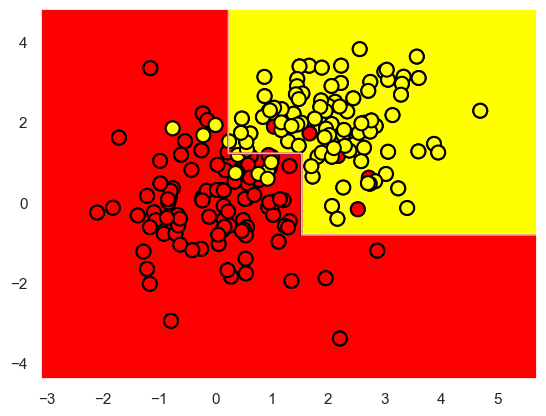

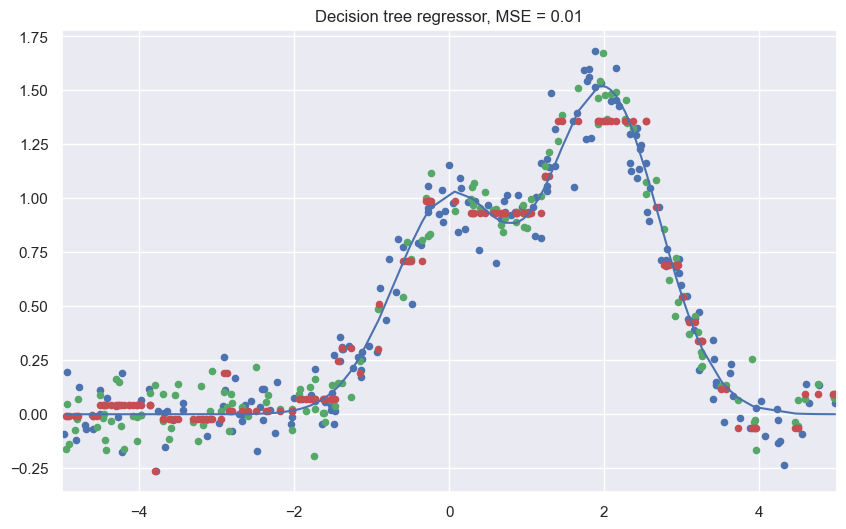

In [3]:
import warnings 
from matplotlib import pyplot as plt 
%matplotlib inline
import numpy as np 
import pandas as pd
import seaborn as sns 
sns.set()
warnings.filterwarnings('ignore') 

plt.figure(figsize = (6,4))
xx = np.linspace(0,1,50)
plt.plot(xx,[2*x*(1-x) for x in xx],label = 'gini')
plt.plot(xx,[4*x*(1-x) for x in xx],label = '2*gini')
plt.plot(xx,[-x*np.log2(x) - (1-x) * np.log2(1-x) for x in xx],label = 'entropy')
plt.plot(xx,[1-max(x,1-x) for x in xx], label = 'missclass')
plt.plot(xx,[2-2*max(x,1-x) for x in xx], label = '2*missclass')
plt.xlabel('p+')
plt.ylabel('criterion')
plt.title('Criteria of quality as a function of p+(binary classification)')
plt.legend()
plt.show()
# 1
np.random.seed(17)
train_data = np.random.normal(size = (100,2))
train_labels = np.zeros(100)

plt.scatter(train_data[:,0],train_data[:,1])
# 2
train_data = np.r_[train_data,np.random.normal(size=(100,2),loc = 2)]
train_labels = np.r_[train_labels,np.ones(100)]

plt.scatter(train_data[:,0],train_data[:,1],c=train_labels[:],cmap='autumn')
print(train_labels.shape)
print(train_data.shape)
plt.figure(figsize=(10,8))
plt.scatter(train_data[:,0], train_data[:,1],c = train_labels,s = 100, cmap= 'autumn', edgecolors='black', linewidth=1.5 )
plt.plot(range(-2,5),range(4,-3,-1))
plt.show()

from sklearn.tree import DecisionTreeClassifier


def get_grid(data):
    x_min,x_max = data[:,0].min()-1,data[:,0].max()+1
    y_min,y_max = data[:,1].min()-1,data[:,1].max()+1
    return np.meshgrid(np.arange(x_min,x_max,0.01),np.arange(y_min,y_max,0.01))

clf_tree =DecisionTreeClassifier(criterion='entropy',max_depth = 3,random_state=17)
# sklearn.tree.DecisionTreeClassifier 类的主要参数为：

# max_depth 树的最大深度；
# max_features 搜索最佳分区时的最大特征数（特征很多时，设置这个参数很有必要，因为基于所有特征搜索分区会很「昂贵」）；
# min_samples_leaf 叶节点的最少样本数。

clf_tree.fit(train_data,train_labels)

xx,yy = get_grid(train_data)
predicted = clf_tree.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)

plt.pcolormesh(xx,yy,predicted,cmap='autumn')
plt.scatter(train_data[:,0],train_data[:,1],c= train_labels,s=100,cmap='autumn',edgecolors='black',linewidth=1.5)

plt.scatter(train_data[:,0],train_data[:,1],c= train_labels,s=100,cmap='autumn',edgecolors='black',linewidth=1.5)
plt.contour(xx,yy,predicted,color='black',linewidths = 1)
from sklearn.tree import DecisionTreeRegressor

n_train = 200
n_test = 150
noise = 0.1

def f(x):
    x = x.ravel()
    return np.exp(-x**2) + 1.5*np.exp(-(x-2)**2)

def generate(n_sample,nosie):
    x = np.random.rand(n_sample) * 10 -5
    x = np.sort(x).ravel()
    y = f(x) + np.random.normal(0.0,noise,n_sample)
    x = x.reshape((n_sample,1))
    return x,y

x_train,y_train = generate(n_train,noise)
x_test,y_test = generate(n_test,noise)
print(x_train.shape)
print(y_train.shape)

reg_tree = DecisionTreeRegressor(criterion='friedman_mse',max_depth=5,random_state=17)

reg_tree.fit(x_train,y_train)
reg_tree_pred = reg_tree.predict(x_test)

plt.figure(figsize=(10,6))
plt.plot(x_test,f(x_test),'b')
plt.scatter(x_train,y_train,c='b',s=20)
plt.scatter(x_test,y_test,c='g',s=20)
plt.scatter(x_test,reg_tree_pred,c='r',s=20)
plt.xlim([-5,5])
plt.title("Decision tree regressor, MSE = %.2f" %
          (np.sum((y_test - reg_tree_pred) ** 2) / n_test))
plt.show()

